<div align="center">

### Lab 4

# National Tsing Hua University

#### Spring 2025

#### 11320IEEM 513600

#### Deep Learning and Industrial Applications
    
## Lab 4: Predicting Stock Price with Deep Learning

</div>

### Introduction

In this lab, we explore the application of time-series datasets using Long Short-Term Memory (LSTM) networks, a type of recurrent neural network, to predict stock prices. Specifically, we will use historical price data from Nvidia to forecast the stock's price for the next day based on the prices of the previous N days. This approach is particularly relevant given the volatile nature of stock markets and the increasing reliance on automated trading systems.

### Objectives

- To understand the fundamentals of LSTM networks and their application in time-series forecasting.
- To develop a predictive model that can accurately forecast Nvidia's stock price for the next day using historical data.

### Dataset

The dataset for this lab is from the "Huge Stock Market Dataset" available on Kaggle. This dataset includes daily prices and volumes for all US stocks and ETFs, with a specific focus on Nvidia (NVDA). The dataset features include:

- **Date**: The recorded data points.
- **Open**: The price at which the stock first traded upon the opening of an exchange on a given trading day.
- **High**: The highest price at which the stock traded during the trading day.
- **Low**: The lowest price at which the stock traded during the trading day.
- **Close**: The price of the stock at closing time.
- **Volume**: The number of shares or contracts traded in a security or an entire market during a given period.
- **OpenInt**: The total number of outstanding derivative contracts, like options or futures. [More details here](https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/discussion/121096)

### References

- [Huge Stock Market Dataset](https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs) for the dataset used in this lab.


## A. Checking and Preprocessing

In [ ]:
import pandas as pd
df = pd.read_csv('/content/nvda.us.txt')
df

,Date,Open,High,Low,Close,Volume,OpenInt
0,1999-01-22,1.6238,1.8092,1.4379,1.5215,18297633,0
1,1999-01-25,1.6423,1.6980,1.5215,1.6793,3445279,0
2,1999-01-26,1.6980,1.7350,1.5311,1.5494,2320993,0
3,1999-01-27,1.5586,1.5957,1.4660,1.5494,1662658,0
4,1999-01-28,1.5494,1.5586,1.5311,1.5401,1540110,0
...,...,...,...,...,...,...,...
4728,2017-11-06,207.2000,209.9800,206.7000,209.6300,9731783,0
4729,2017-11-07,210.5500,212.9000,210.0560,212.0000,10671815,0
4730,2017-11-08,211.8500,212.0000,207.2400,209.1600,13033902,0
4731,2017-11-09,205.2700,206.3300,200.3700,205.3200,23895006,0


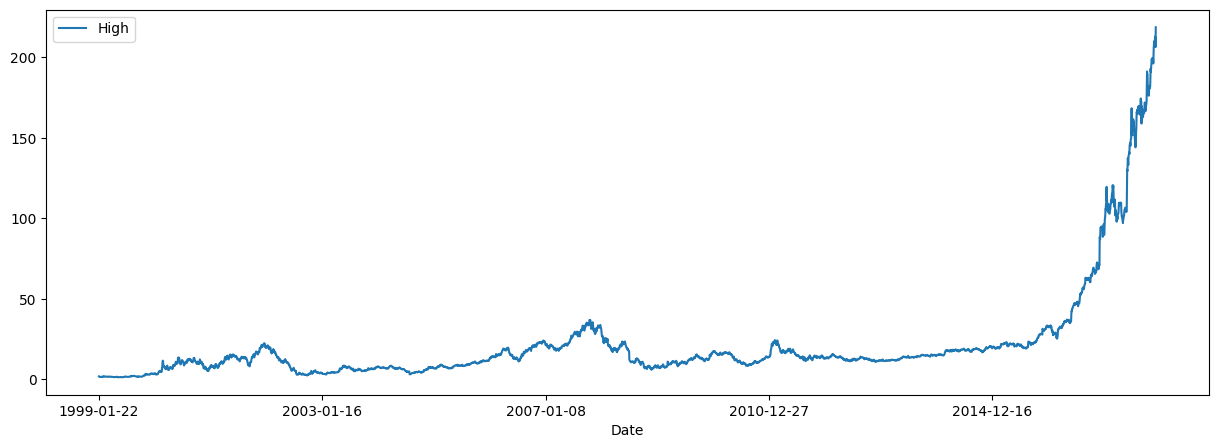

In [ ]:
plot = df.plot('Date', 'High', figsize=(15, 5))

In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4733 entries, 0 to 4732
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     4733 non-null   object 
 1   Open     4733 non-null   float64
 2   High     4733 non-null   float64
 3   Low      4733 non-null   float64
 4   Close    4733 non-null   float64
 5   Volume   4733 non-null   int64  
 6   OpenInt  4733 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 259.0+ KB


In [ ]:
# checking for null values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
OpenInt,0


In [ ]:
df = df.dropna()

In [ ]:
df.shape

(4733, 7)

In [ ]:
df.describe()

,Open,High,Low,Close,Volume,OpenInt
count,4733.000000,4733.000000,4733.000000,4733.000000,4.733000e+03,4733.0
mean,20.796242,21.157332,20.420417,20.805404,1.615287e+07,0.0
std,30.236284,30.615622,29.792958,30.263705,1.272446e+07,0.0
min,1.298900,1.317500,1.233900,1.261900,0.000000e+00,0.0
25%,7.988300,8.247900,7.756400,7.978900,8.181100e+06,0.0
50%,12.963000,13.238000,12.721000,12.990000,1.390271e+07,0.0
75%,19.141000,19.418000,18.778000,19.106000,2.051602e+07,0.0
max,213.080000,218.670000,211.630000,216.140000,2.496659e+08,0.0


#### Converting the DataFrame to a NumPy Array

In [ ]:
def create_sequences(input_data, output_data, window_size, step):
    sequences = []
    labels = []
    for i in range(0, len(input_data) - window_size, step):
        sequences.append(input_data[i:(i + window_size)])
        labels.append(output_data[i + window_size])
    return np.array(sequences), np.array(labels)

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Select features
features = df[['Open', 'High', 'Low', 'Close']]
labels = df['High'].shift(-1)  # Next day's high price as label

X, y = create_sequences(features, labels, window_size=10, step=15)

print(f'Shape of data X: {X.shape}')
print(f'Shape of data y: {y.shape}')

# split the hold-out tests
ind = np.linspace(0, len(X)-1, num=int(len(X)*0.1), dtype=int) # 10% hold-out
x_test = X[ind]
y_test = y[ind]
all_ind = np.arange(len(X))
remains_ind = np.delete(all_ind, ind)

X = X[remains_ind]
y = y[remains_ind]

# shuffle dataset
ind = np.random.permutation(len(X))
X = X[ind]
y = y[ind]
split_point = int(X.shape[0]*0.8)

x_train = X[:split_point]
y_train = y[:split_point]
x_val = X[split_point:]
y_val = y[split_point:]

print(f'Shape of data x_train: {x_train.shape}')
print(f'Shape of data y_train: {y_train.shape}')
print(f'Shape of data x_val: {x_val.shape}')
print(f'Shape of data y_val: {y_val.shape}')
print(f'Shape of data x_test: {x_test.shape}')
print(f'Shape of data y_test: {y_test.shape}')

# Convert to PyTorch tensors
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()

x_val = torch.from_numpy(x_val).float()
y_val = torch.from_numpy(y_val).float()

x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test).float()

batch_size = 32

# Create datasets
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Number of samples in training and validation are {len(train_loader.dataset)} and {len(val_loader.dataset)}.')

Shape of data X: (315, 10, 4)
Shape of data y: (315,)
Shape of data x_train: (227, 10, 4)
Shape of data y_train: (227,)
Shape of data x_val: (57, 10, 4)
Shape of data y_val: (57,)
Shape of data x_test: (31, 10, 4)
Shape of data y_test: (31,)
Number of samples in training and validation are 227 and 57.


## B. Defining Neural Networks

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

## C. Training the Neural Network

In [ ]:
# Check your GPU status.
!nvidia-smi

Wed Apr 30 16:51:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

train_losses = []
val_losses = []

epochs = 100

model = LSTMModel(input_dim=4, hidden_dim=500, num_layers=2, output_dim=1).cuda()
print(model)

best_val_loss = float('inf')

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
lr_scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0)

for epoch in tqdm(range(epochs)):
    # Training
    model.train()
    total_loss = 0.0

    for features, labels in train_loader:
        features = features.cuda()
        labels = labels.cuda()
        outputs = model(features).squeeze(-1)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Learning rate update
    lr_scheduler.step()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for features, labels in val_loader:
            features = features.cuda()
            labels = labels.cuda()
            outputs = model(features).squeeze(-1)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    # Checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Val loss: {avg_val_loss:.4f}, Best Val loss: {best_val_loss:.4f}')

    # Store performance
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

In [ ]:
import pandas as pd, numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

# （window_size, step）
CONFIGS = [(30, 1), (60, 1), (60, 5)]

def build_loader(prices, window, step, batch=64, split=0.8):
    X, y = [], []
    for i in range(0, len(prices) - window, step):
        X.append(prices[i:i+window])
        y.append(prices[i+window])
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32)
    cut = int(len(X)*split)
    ds_train = TensorDataset(X[:cut],  y[:cut])
    ds_val   = TensorDataset(X[cut:],  y[cut:])
    return (DataLoader(ds_train, batch, shuffle=True),
            DataLoader(ds_val,   batch, shuffle=False))

# 單次訓練並回傳驗證MSE
def run_one_conf(train_loader, val_loader, epochs=100):
    model = LSTMModel(input_dim=1, hidden_dim=500, num_layers=2, output_dim=1).cuda()
    crit  = nn.MSELoss(); opt = Adam(model.parameters(), 1e-3)
    sch   = CosineAnnealingLR(opt, T_max=epochs)
    best  = np.inf
    for _ in range(epochs):
        model.train()
        for x, t in train_loader:
            x, t = x.cuda(), t.cuda()
            loss = crit(model(x).squeeze(-1), t)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        # --- validation ---
        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for x, t in val_loader:
                x, t = x.cuda(), t.cuda()
                val_loss += crit(model(x).squeeze(-1), t).item()
        val_loss /= len(val_loader)
        best = min(best, val_loss)
    return best

prices = df['Close'].values
prices = (prices - prices.mean()) / prices.std()

# 三組實驗
records = []
for w, s in CONFIGS:
    tr_loader, val_loader = build_loader(prices, w, s)
    mse = run_one_conf(tr_loader, val_loader)
    records.append({'window': w, 'step': s, 'MSE': mse})
    print(f'window={w}, step={s} → MSE={mse:.6f}')

result_df = pd.DataFrame(records)
display(result_df)

<ipython-input-16-1e51b86a13b7>:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)


window=30, step=1 → MSE=0.134416
window=60, step=1 → MSE=0.047660
window=60, step=5 → MSE=0.019918


,window,step,MSE
0,30,1,0.134416
1,60,1,0.047660
2,60,5,0.019918


In [ ]:
import pandas as pd, numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

def create_sequences(arr, window, step, target_col):
    X, y = [], []
    for i in range(0, len(arr) - window, step):
        X.append(arr[i:i+window])
        y.append(arr[i+window, target_col])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=500, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

def train_one(X, y, epochs=60, batch=64):
    cut = int(len(X) * 0.8)
    tl  = DataLoader(TensorDataset(X[:cut],  y[:cut]),  batch_size=batch, shuffle=True)
    vl  = DataLoader(TensorDataset(X[cut:],  y[cut:]),  batch_size=batch, shuffle=False)

    model = LSTMModel(input_dim=X.shape[-1]).cuda()
    crit  = nn.MSELoss()
    opt   = Adam(model.parameters(), 1e-3)
    sch   = CosineAnnealingLR(opt, T_max=epochs)

    best = np.inf
    for _ in tqdm(range(epochs), leave=False):
        model.train()
        for a, b in tl:
            a, b = a.cuda(), b.cuda()
            loss = crit(model(a).squeeze(-1), b)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        # --- Val ---
        model.eval(); val = 0.0
        with torch.no_grad():
            for a, b in vl:
                a, b = a.cuda(), b.cuda()
                val += crit(model(a).squeeze(-1), b).item()
        val /= len(vl)
        best = min(best, val)
    return best


# 所有候選欄位
cols_dict = {
    'Close'                : ['Close'],
    'Close+Volume'         : ['Close', 'Volume'],
    'OHLC'                 : ['Open', 'High', 'Low', 'Close'],
    'OHLC+Volume'          : ['Open', 'High', 'Low', 'Close', 'Volume'],
}

WINDOW, STEP = 60, 5
results = []

for name, cols in cols_dict.items():
    feat = df[cols].astype('float32').values
    mean, std = feat.mean(axis=0), feat.std(axis=0)
    feat = (feat - mean) / std
    X, y = create_sequences(feat, WINDOW, STEP, target_col=cols.index('Close'))

    if X.ndim == 2: X = X.unsqueeze(-1)
    mse = train_one(X, y)
    results.append({'combo': name, 'features': cols, 'MSE': mse})
    print(f"{name:20s} → MSE = {mse:.5f}")

res_df = pd.DataFrame(results).sort_values('MSE')
display(res_df[['combo', 'MSE']])

  0%|          | 0/60 [00:00<?, ?it/s]

Close                → MSE = 0.03565


  0%|          | 0/60 [00:00<?, ?it/s]

Close+Volume         → MSE = 0.09493


  0%|          | 0/60 [00:00<?, ?it/s]

OHLC                 → MSE = 0.01167


  0%|          | 0/60 [00:00<?, ?it/s]

OHLC+Volume          → MSE = 0.12690


,combo,MSE
2,OHLC,0.011675
0,Close,0.035648
1,Close+Volume,0.094926
3,OHLC+Volume,0.126899


In [ ]:
def make_sequences(arr, win=60, step=5, target_col=3):
    X, y = [], []
    for i in range(0, len(arr)-win, step):
        X.append(arr[i:i+win])
        y.append(arr[i+win, target_col])
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    if X.ndim == 2: X = X.unsqueeze(-1)     # 單一特徵 -> [N,T,1]
    return X, y

def run_once(X, y, epochs=50, batch=64):
    cut = int(len(X)*0.8)
    tl  = DataLoader(TensorDataset(X[:cut],  y[:cut]),  batch_size=batch, shuffle=True)
    vl  = DataLoader(TensorDataset(X[cut:],  y[cut:]),  batch_size=batch, shuffle=False)

    model = LSTMModel(input_dim=X.shape[-1]).cuda()
    opt   = Adam(model.parameters(), 1e-3)
    sch   = CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    best  = np.inf

    for _ in tqdm(range(epochs), leave=False):
        # ---- train ----
        model.train()
        for a,b in tl:
            a,b = a.cuda(), b.cuda()
            loss = crit(model(a).squeeze(-1), b)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        # ---- val ----
        model.eval(); v = 0.0
        with torch.no_grad():
            for a,b in vl:
                a,b = a.cuda(), b.cuda()
                v += crit(model(a).squeeze(-1), b).item()
        v /= len(vl); best = min(best, v)
    return best

cols = ['Open','High','Low','Close']
arr  = df[cols].astype('float32').values

# (a)無正規化
X_raw, y_raw = make_sequences(arr, target_col=3)

# (b)正規化
mean, std = arr.mean(axis=0), arr.std(axis=0)
arr_norm  = (arr - mean) / std
X_norm, y_norm = make_sequences(arr_norm, target_col=3)

mse_raw  = run_once(X_raw,  y_raw)
mse_norm = run_once(X_norm, y_norm)

print(f"Without normalization  MSE = {mse_raw:.4f}")
print(f"With Z-score      MSE = {mse_norm:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Without normalization  MSE = 3499.0507
With Z-score      MSE = 0.1381


#### Visualizing the model performance

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'])

plt.show()

## D. Evaluating Your Trained Model

In [ ]:
# Load the trained weights
model.load_state_dict(torch.load('best_model.pth'))

# Set the model to evaluation mode
model.eval()

test_correct = 0
test_total = 0

pred_value = []
actual_value = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.cuda()
        outputs = model(features).squeeze(-1)
        pred_value.append(outputs.cpu())
        actual_value.append(labels)

pred_value = torch.cat(pred_value)
actual_value = torch.cat(actual_value)

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(pred_value[:])
plt.plot(actual_value[:])
plt.xlabel('Day')
plt.ylabel('Price')
plt.legend(['Pred', 'Actual'])

plt.show()

In [ ]:
import nbformat
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Define the path to the original notebook
notebook_path = '/content/drive/MyDrive/Colab Notebooks/lab4.ipynb'

# Define the path for the cleaned output notebook
cleaned_path = '/content/drive/MyDrive/Colab Notebooks/lab4.ipynb'

# Load the notebook from the specified path
with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Remove widget metadata to prevent GitHub rendering issues
if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']

# Save the cleaned notebook to the specified path
with open(cleaned_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)